### Etape1: Collecte des données Import et Analyse du dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
data = pd.read_csv('german_credit_data.csv')

In [4]:
data.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


### Etape 2 : Analyse exploratoire

In [14]:
data.shape

(1000, 10)

Nous avons 1000 lignes et 11 colonnes pour notre dataset

In [15]:
data.dtypes

Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object

In [ ]:
#Suppression de la colonne Unnamed car unitile
data.drop(columns=["Unnamed: 0"], inplace=True)

In [ ]:
data.head(5)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.2+ KB


### Explication des variables

| Colonne          | Type   | Signification approximative   |
| ---------------- | ------ | ------------------------- |
| Age              | int64  | âge du client             |
| Sex              | object | sexe                      |
| Job              | int64  | catégorie professionnelle |
| Housing          | object | logement                  |
| Saving accounts  | object | compte épargne            |
| Checking account | object | compte courant            |
| Credit amount    | int64  | montant du crédit         |
| Duration         | int64  | durée du crédit           |
| Purpose          | object | objectif du crédit        |
| Risk             | object | risque crédit (cible)     |




In [31]:
data['Job'].unique()

array([2, 1, 3, 0])

In [32]:
data['Risk'].unique()

array(['good', 'bad'], dtype=object)

Il est très important d'encoder la variable Target ici

good → 0

bad → 1

#### Etape 3 : Analyse exploratoire - Visualisation - Nettoyage avec pandas

In [33]:
#Checking for missing values

data.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [36]:
data.duplicated().sum()

np.int64(0)

Il n'ya pas de valeures dupliquées

In [103]:
data["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

<Axes: >

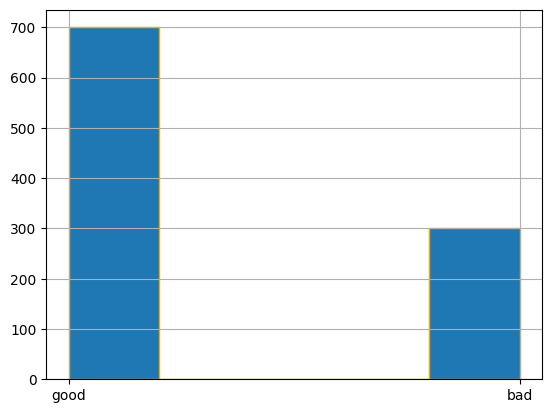

In [117]:
data["Risk"].hist(edgecolor='orange', bins=5)

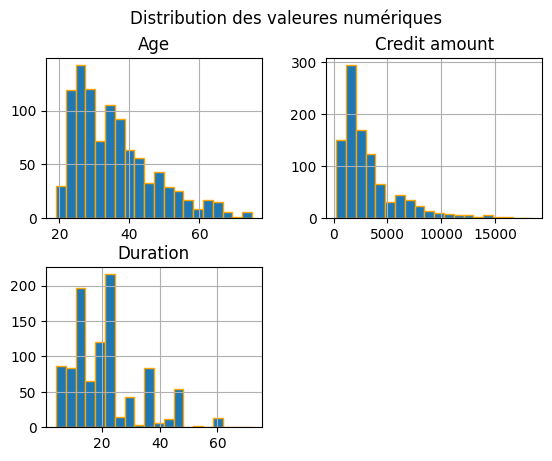

In [104]:
data[["Age","Credit amount","Duration"]].hist(bins=20, edgecolor ="orange")
plt.suptitle("Distribution des valeures numériques")
plt.show()

#### Afficher la distribution des variables categorielles afin de bien comprendre les donnees

In [105]:
data.query("Age>= 20")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


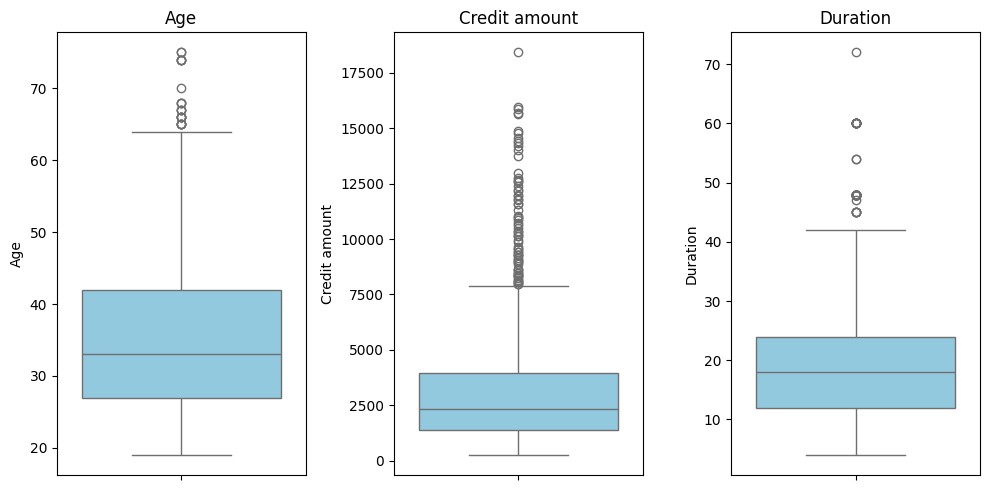

In [106]:
plt.figure(figsize=(10,5))

for i , col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y = data[col], color ="skyblue")
    plt.title(col)
plt.tight_layout()
plt.show()

##### Le dataset représente une population principalement jeune (22 à 46 ans), qui sollicite des crédits de faibles montants sur des durées courtes (1 à 2 ans).
##### Cependant,il existe une minorité de profils qui empruntent de très grosses sommes sur des périodes particulièrement longues.

In [107]:
data.query("Duration > 65")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad


In [108]:
categorical_columns = ["Sex","Job","Housing","Saving accounts","Checking account","Purpose"]         

C:\Users\HP\AppData\Local\Temp\ipykernel_17288\2442038514.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = data , x = col , palette="Set2", order= data[col].value_counts().index)
C:\Users\HP\AppData\Local\Temp\ipykernel_17288\2442038514.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = data , x = col , palette="Set2", order= data[col].value_counts().index)
C:\Users\HP\AppData\Local\Temp\ipykernel_17288\2442038514.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = data , x = col , palette="Set2", order= data[c

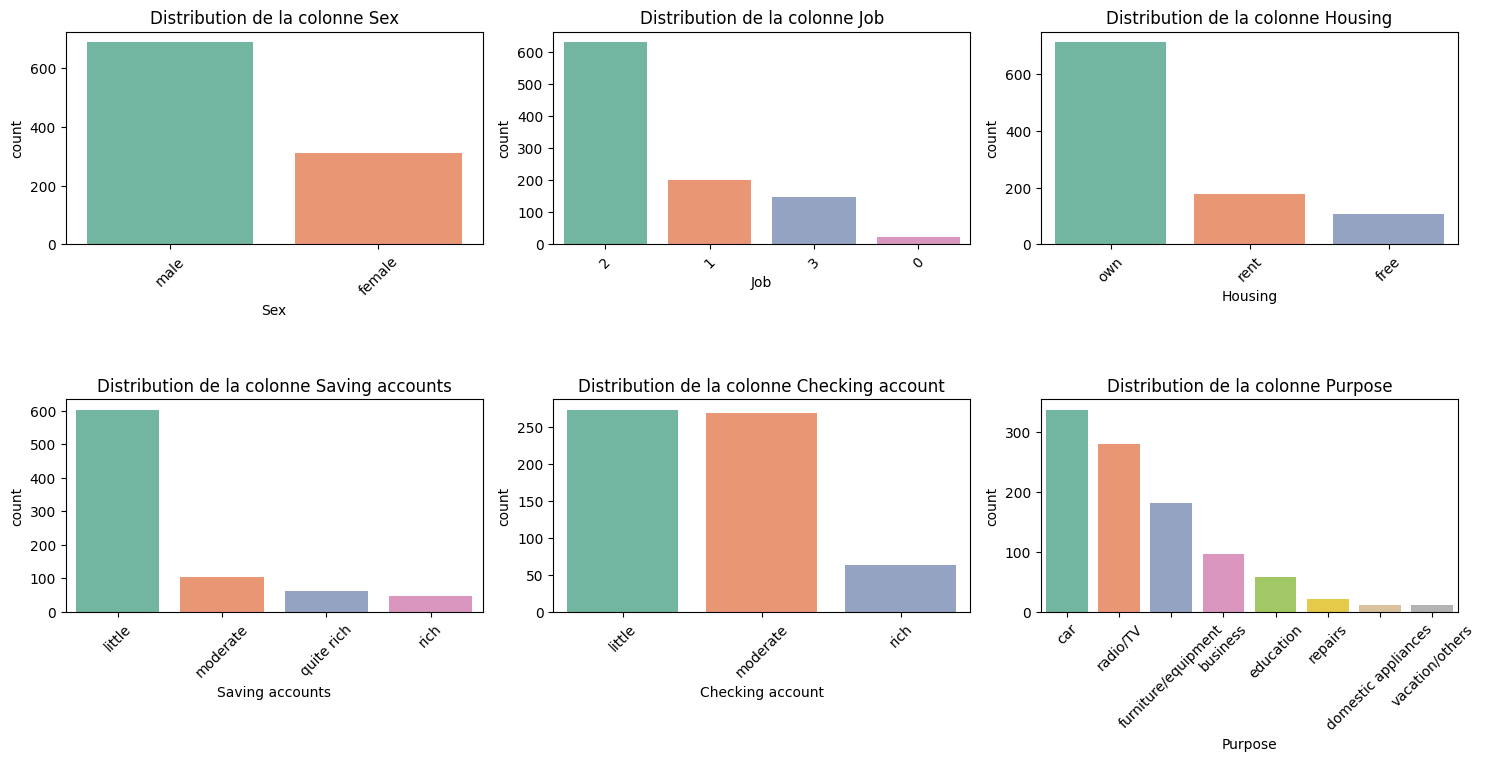

In [121]:
plt.figure(figsize=(15,10))

for i , col in enumerate(categorical_columns):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data = data , x = col , palette="Set2", order= data[col].value_counts().index)
    plt.title(f"Distribution de la colonne {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [124]:
#Correlation entre l'age,l'emploi,le montant du credit et la duree
correlation = data[["Age","Job","Credit amount","Duration"]].corr()

correlation

,Age,Job,Credit amount,Duration
Age,1.000000,0.015673,0.032716,-0.036136
Job,0.015673,1.000000,0.285385,0.210910
Credit amount,0.032716,0.285385,1.000000,0.624984
Duration,-0.036136,0.210910,0.624984,1.000000


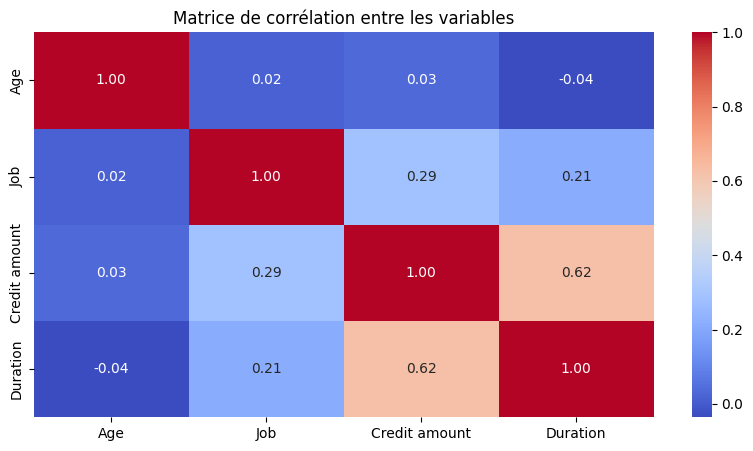

In [125]:
plt.figure(figsize=(10,5))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation entre les variables")
plt.show()

In [130]:
#La moyenne des montants en fonction du Job

data.groupby("Job")["Credit amount"].mean()

Job
0    2745.136364
1    2358.520000
2    3070.965079
3    5435.493243
Name: Credit amount, dtype: float64

In [131]:
#La moyenne des montants en fonction du Genre
data.groupby("Sex")["Credit amount"].mean()

Sex
female    2877.774194
male      3448.040580
Name: Credit amount, dtype: float64

In [134]:
#La moyenne des montants en fonction du Genre
data.groupby("Purpose")["Credit amount"].mean()

Purpose
business               4158.041237
car                    3768.192878
domestic appliances    1498.000000
education              2879.203390
furniture/equipment    3066.988950
radio/TV               2487.653571
repairs                2728.090909
vacation/others        8209.333333
Name: Credit amount, dtype: float64

In [135]:
data.pivot_table(
    values='Credit amount',
    index='Purpose',
    columns='Risk',
    aggfunc='mean'
)

Risk,bad,good
Purpose,,
business,5622.441176,3367.730159
car,4221.952830,3559.974026
domestic appliances,1571.000000,1461.500000
education,3151.869565,2705.000000
furniture/equipment,3645.500000,2794.195122
radio/TV,2780.209677,2404.449541
repairs,2791.125000,2692.071429
vacation/others,11566.000000,5811.714286


In [ ]:
data.pivot_table(
    values='Duration',
    index='Housing',
    columns='Risk',
    aggfunc='mean')

Risk,bad,good
Housing,,
free,30.022727,25.687500
own,23.940860,19.053131
rent,24.057143,16.146789
